In [1]:

%matplotlib inline
import glob, os, sys, timeit
import matplotlib
import numpy as np

import jaxqsofit
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

path_ex = '.' #os.path.join(pyqsofit.__path__[0], '..', 'example')

# create a header
hdr0 = fits.Header()
hdr0['Author'] = 'Hengxiao Guo'
primary_hdu = fits.PrimaryHDU(header=hdr0)

In [2]:
"""
In this table, we specify the priors / initial conditions and boundaries for the line fitting parameters.
"""

line_priors = np.rec.array([
    (6564.61, 'Ha', 6400, 6800, 'Ha_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 0, 0, 0, 0.05, 1),
    (6564.61, 'Ha', 6400, 6800, 'Ha_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (6549.85, 'Ha', 6400, 6800, 'NII6549', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 1, 0.001, 1),
    (6585.28, 'Ha', 6400, 6800, 'NII6585', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 1, 0.003, 1),
    (6718.29, 'Ha', 6400, 6800, 'SII6718', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),
    (6732.67, 'Ha', 6400, 6800, 'SII6732', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 5e-3, 1, 1, 2, 0.001, 1),

    (4862.68, 'Hb', 4640, 5100, 'Hb_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.01, 0, 0, 0, 0.01, 1),
    (4862.68, 'Hb', 4640, 5100, 'Hb_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (4960.30, 'Hb', 4640, 5100, 'OIII4959c', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    (5008.24, 'Hb', 4640, 5100, 'OIII5007c', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.01, 1, 1, 0, 0.004, 1),
    (4960.30, 'Hb', 4640, 5100, 'OIII4959w',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.004,  0.01,  2, 2, 0, 0.001, 1),
    (5008.24, 'Hb', 4640, 5100, 'OIII5007w',   1, 0.0, 0.0, 1e10, 3e-3, 2.3e-4, 0.004,  0.01,  2, 2, 0, 0.002, 1),
    #(4687.02, 'Hb', 4640, 5100, 'HeII4687_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.004,  0.05,   0.005, 0, 0, 0, 0.001, 1),
    #(4687.02, 'Hb', 4640, 5100, 'HeII4687_na', 1, 0.0, 0.0, 1e10, 1e-3, 2.3e-4, 0.00169, 0.005, 1, 1, 0, 0.001, 1),

    #(3934.78, 'CaII', 3900, 3960, 'CaII3934' , 2, 0.0, 0.0, 1e10, 1e-3, 3.333e-4, 0.00169, 0.01, 99, 0, 0, -0.001, 1),

    #(3728.48, 'OII', 3650, 3800, 'OII3728', 1, 0.0, 0.0, 1e10, 1e-3, 3.333e-4, 0.00169, 0.01, 1, 1, 0, 0.001, 1),

    #(3426.84, 'NeV', 3380, 3480, 'NeV3426',    1, 0.0, 0.0, 1e10, 1e-3, 3.333e-4, 0.00169, 0.01, 0, 0, 0, 0.001, 1),
    #(3426.84, 'NeV', 3380, 3480, 'NeV3426_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.0025,   0.02,   0.01, 0, 0, 0, 0.001, 1),

    (2798.75, 'MgII', 2700, 2900, 'MgII_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 0, 0, 0, 0.05, 1),
    (2798.75, 'MgII', 2700, 2900, 'MgII_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),

    (1908.73, 'CIII', 1700, 1970, 'CIII_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 99, 0, 0, 0.01, 1),
    #(1908.73, 'CIII', 1700, 1970, 'CIII_na',   1, 0.0, 0.0, 1e10, 1e-3, 5e-4,  0.00169, 0.01,  1, 1, 0, 0.002, 1),
    #(1892.03, 'CIII', 1700, 1970, 'SiIII1892', 1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.003, 1, 1, 0, 0.005, 1),
    #(1857.40, 'CIII', 1700, 1970, 'AlIII1857', 1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.003, 1, 1, 0, 0.005, 1),
    #(1816.98, 'CIII', 1700, 1970, 'SiII1816',  1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.0002, 1),
    #(1786.7,  'CIII', 1700, 1970, 'FeII1787',  1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.0002, 1),
    #(1750.26, 'CIII', 1700, 1970, 'NIII1750',  1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.001, 1),
    #(1718.55, 'CIII', 1700, 1900, 'NIV1718',   1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015,  0.01,  1, 1, 0, 0.001, 1),

    (1549.06, 'CIV', 1500, 1700, 'CIV_br', 2, 0.0, 0.0, 1e10, 5e-3, 0.004, 0.05, 0.015, 0, 0, 0, 0.05, 1),
    # (1549.06, 'CIV', 1500, 1700, 'CIV_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 1, 1, 0, 0.002, 1),
    #(1640.42, 'CIV', 1500, 1700, 'HeII1640',    1, 0.0, 0.0, 1e10, 1e-3, 5e-4,   0.00169, 0.008, 1, 1, 0, 0.002, 1),
    #(1663.48, 'CIV', 1500, 1700, 'OIII1663',    1, 0.0, 0.0, 1e10, 1e-3, 5e-4,   0.00169, 0.008, 1, 1, 0, 0.002, 1),
    #(1640.42, 'CIV', 1500, 1700, 'HeII1640_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.0025, 0.02,   0.008, 1, 1, 0, 0.002, 1),
    #(1663.48, 'CIV', 1500, 1700, 'OIII1663_br', 1, 0.0, 0.0, 1e10, 5e-3, 0.0025, 0.02,   0.008, 1, 1, 0, 0.002, 1),

    #(1402.06, 'SiIV', 1290, 1450, 'SiIV_OIV1', 1, 0.0, 0.0, 1e10, 5e-3, 0.002, 0.05,  0.015, 1, 1, 0, 0.05, 1),
    #(1396.76, 'SiIV', 1290, 1450, 'SiIV_OIV2', 1, 0.0, 0.0, 1e10, 5e-3, 0.002, 0.05,  0.015, 1, 1, 0, 0.05, 1),
    #(1335.30, 'SiIV', 1290, 1450, 'CII1335',   1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015, 0.01,  1, 1, 0, 0.001, 1),
    #(1304.35, 'SiIV', 1290, 1450, 'OI1304',    1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.015, 0.01,  1, 1, 0, 0.001, 1),

    (1215.67, 'Lya', 1150, 1290, 'Lya_br', 3, 0.0, 0.0, 1e10, 5e-3, 0.002, 0.05, 0.02, 0, 0, 0, 0.05, 1),
    (1240.14, 'Lya', 1150, 1290, 'NV1240', 1, 0.0, 0.0, 1e10, 2e-3, 0.001, 0.01, 0.005, 0, 0, 0, 0.002, 1),
    # (1215.67, 'Lya', 1150, 1290, 'Lya_na', 1, 0.0, 0.0, 1e10, 1e-3, 5e-4, 0.00169, 0.01, 0, 0, 0, 0.002, 1),
    ],

    formats='float32,    a20,  float32, float32,      a20,  int32, float32, float32, float32, float32, float32, float32, float32,   int32,  int32,  int32, float32, int32',
    names=' lambda, compname,   minwav,  maxwav, linename, ngauss,  inisca,  minsca,  maxsca,  inisig,  minsig,  maxsig,    voff,  vindex, windex, findex,  fvalue,  vary')

# Header
hdr1 = fits.Header()
hdr1['lambda'] = 'Vacuum Wavelength in Ang'
hdr1['minwav'] = 'Lower complex fitting wavelength range'
hdr1['maxwav'] = 'Upper complex fitting wavelength range'
hdr1['ngauss'] = 'Number of Gaussians for the line'

# Can be set to negative for absorption lines if you want
hdr1['inisca'] = 'Initial guess of line scale [flux]'
hdr1['minsca'] = 'Lower range of line scale [flux]'
hdr1['maxsca'] = 'Upper range of line scale [flux]'

hdr1['inisig'] = 'Initial guess of linesigma [lnlambda]'
hdr1['minsig'] = 'Lower range of line sigma [lnlambda]'
hdr1['maxsig'] = 'Upper range of line sigma [lnlambda]'

hdr1['voff  '] = 'Limits on velocity offset from the central wavelength [lnlambda]'
hdr1['vindex'] = 'Entries w/ same NONZERO vindex constrained to have same velocity'
hdr1['windex'] = 'Entries w/ same NONZERO windex constrained to have same width'
hdr1['findex'] = 'Entries w/ same NONZERO findex have constrained flux ratios'
hdr1['fvalue'] = 'Relative scale factor for entries w/ same findex'

hdr1['vary'] = 'Whether or not to vary the parameter (set to 0 to fix the line parameter to initial values)'

# Save line info
hdu1 = fits.BinTableHDU(data=line_priors, header=hdr1, name='line_priors')

In [3]:
"""
In this table, we specify the windows and priors / initial conditions and boundaries for the continuum fitting parameters.
"""

conti_priors = np.rec.array([
    ('Fe_uv_norm',  0.0,   0.0,   1e10,  1), # Normalization of the MgII Fe template [flux]
    ('Fe_uv_FWHM',  3000,  1200,  18000, 1), # FWHM of the MgII Fe template [AA]
    ('Fe_uv_shift', 0.0,   -0.01, 0.01,  1), # Wavelength shift of the MgII Fe template [lnlambda]
    ('Fe_op_norm',  0.0,   0.0,   1e10,  1), # Normalization of the Hbeta/Halpha Fe template [flux]
    ('Fe_op_FWHM',  3000,  1200,  18000, 1), # FWHM of the Hbeta/Halpha Fe template [AA]
    ('Fe_op_shift', 0.0,   -0.01, 0.01,  1), # Wavelength shift of the Hbeta/Halpha Fe template [lnlambda]
    ('PL_norm',     1.0,   0.0,   1e10,  1), # Normalization of the power-law (PL) continuum f_lambda = (lambda/3000)^-alpha
    ('PL_slope',    -1.5,  -5.0,  3.0,   1), # Slope of the power-law (PL) continuum
    ('Blamer_norm', 0.0,   0.0,   1e10,  1), # Normalization of the Balmer continuum at < 3646 AA [flux] (Dietrich et al. 2002)
    ('Balmer_Te',   15000, 10000, 50000, 1), # Te of the Balmer continuum at < 3646 AA [K?]
    ('Balmer_Tau',  0.5,   0.1,   2.0,   1), # Tau of the Balmer continuum at < 3646 AA
    ('conti_a_0',   0.0,   None,  None,  1), # 1st coefficient of the polynomial continuum
    ('conti_a_1',   0.0,   None,  None,  1), # 2nd coefficient of the polynomial continuum
    ('conti_a_2',   0.0,   None,  None,  1), # 3rd coefficient of the polynomial continuum
    # Note: The min/max bounds on the conti_a_0 coefficients are ignored by the code,
    # so they can be determined automatically for numerical stability.
    ],

    formats = 'a20,  float32, float32, float32, int32',
    names = 'parname, initial,   min,     max,     vary')

hdr3 = fits.Header()
hdr3['ini'] = 'Initial guess of line scale [flux]'
hdr3['min'] = 'FWHM of the MgII Fe template'
hdr3['max'] = 'Wavelength shift of the MgII Fe template'

hdr3['vary'] = 'Whether or not to vary the parameter (set to 0 to fix the continuum parameter to initial values)'


hdu3 = fits.BinTableHDU(data=conti_priors, header=hdr3, name='conti_priors')

In [4]:
Table(line_priors)

lambda,compname,minwav,maxwav,linename,ngauss,inisca,minsca,maxsca,inisig,minsig,maxsig,voff,vindex,windex,findex,fvalue,vary
float32,bytes20,float32,float32,bytes20,int32,float32,float32,float32,float32,float32,float32,float32,int32,int32,int32,float32,int32
6564.61,Ha,6400.0,6800.0,Ha_br,2,0.0,0.0,1e+10,0.005,0.004,0.05,0.015,0,0,0,0.05,1
6564.61,Ha,6400.0,6800.0,Ha_na,1,0.0,0.0,1e+10,0.001,0.0005,0.00169,0.01,1,1,0,0.002,1
6549.85,Ha,6400.0,6800.0,NII6549,1,0.0,0.0,1e+10,0.001,0.00023,0.00169,0.005,1,1,1,0.001,1
6585.28,Ha,6400.0,6800.0,NII6585,1,0.0,0.0,1e+10,0.001,0.00023,0.00169,0.005,1,1,1,0.003,1
6718.29,Ha,6400.0,6800.0,SII6718,1,0.0,0.0,1e+10,0.001,0.00023,0.00169,0.005,1,1,2,0.001,1
6732.67,Ha,6400.0,6800.0,SII6732,1,0.0,0.0,1e+10,0.001,0.00023,0.00169,0.005,1,1,2,0.001,1
4862.68,Hb,4640.0,5100.0,Hb_br,2,0.0,0.0,1e+10,0.005,0.004,0.05,0.01,0,0,0,0.01,1
4862.68,Hb,4640.0,5100.0,Hb_na,1,0.0,0.0,1e+10,0.001,0.00023,0.00169,0.01,1,1,0,0.002,1
4960.3,Hb,4640.0,5100.0,OIII4959c,1,0.0,0.0,1e+10,0.001,0.00023,0.00169,0.01,1,1,0,0.002,1


In [10]:
# Requried
#data = fits.open(os.path.join('../isaque_pyqsofit/example', 'data/spec-0332-52367-0639.fits'))
data = fits.open(os.path.join('../isaque_pyqsofit/example', 'data/spec-0266-51602-0107.fits'))
#
lam = 10 ** data[1].data['loglam']  # OBS wavelength [A]
flux = data[1].data['flux']  # OBS flux [erg/s/cm^2/A]
err = 1 / np.sqrt(data[1].data['ivar'])  # 1 sigma error
z = data[2].data['z'][0]  # Redshift

# Optional
ra = data[0].header['plug_ra']  # RA
dec = data[0].header['plug_dec']  # DEC
plateid = data[0].header['plateid']  # SDSS plate ID
mjd = data[0].header['mjd']  # SDSS MJD
fiberid = data[0].header['fiberid']  # SDSS fiber ID

[20.345263 13.654755  6.967988 ... 21.597372 21.61936  22.212591]


sample: 100%|██████████| 220/220 [03:14<00:00,  1.13it/s, 255 steps of size 4.87e-02. acc. prob=0.95]


max data        : 122.59687844005006
max total model : 93.1568657928737
max PL          : 10.683046941631964
max host        : 29.25469716744615
max FeII UV     : 0.0
max FeII opt    : 0.0
max Balmer cont : 7.388354992494858e-266
max lines       : 68.19887408540286


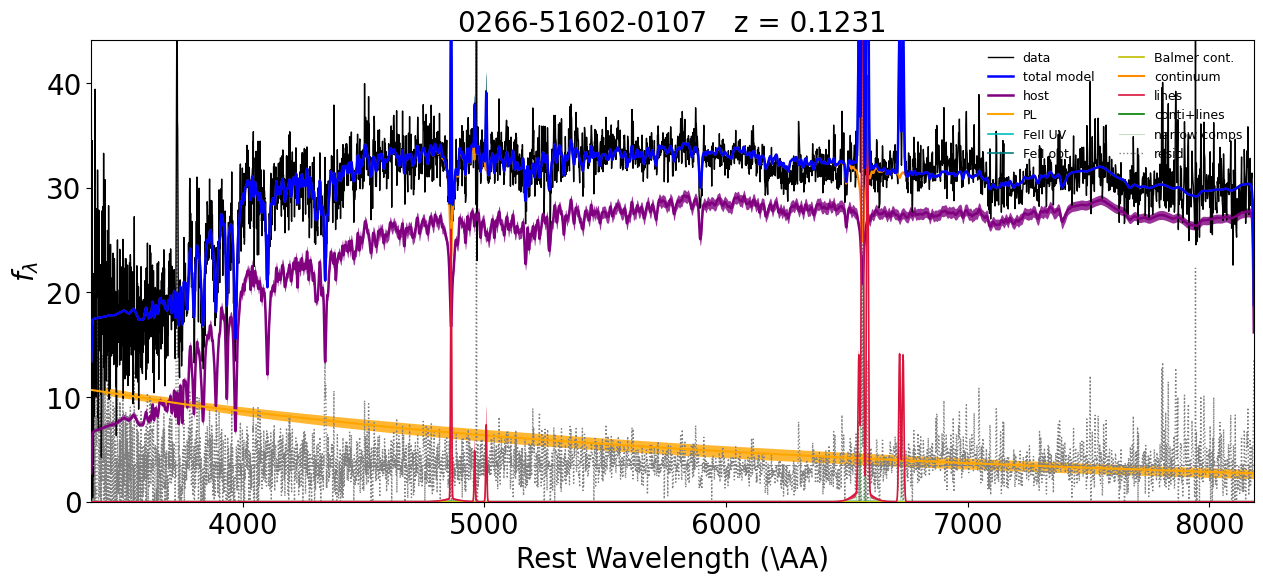

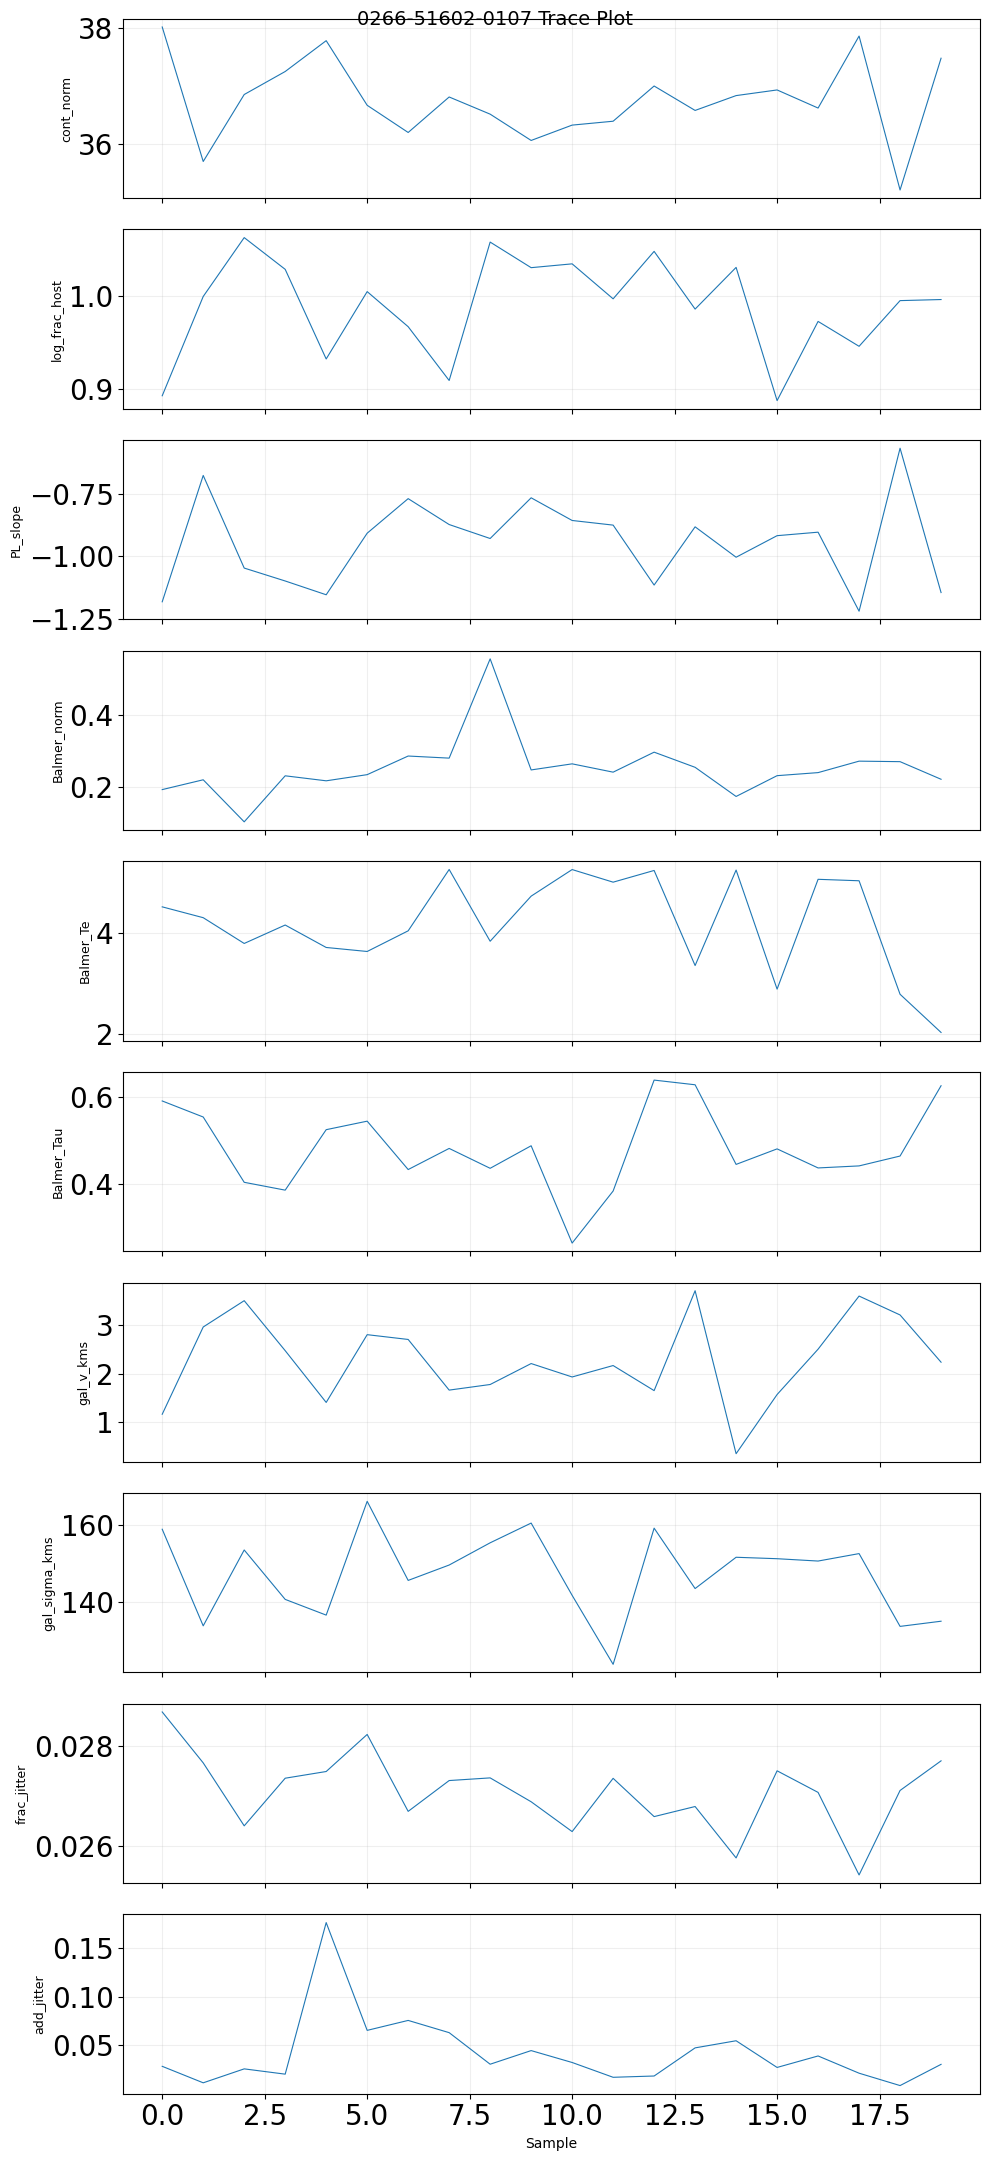

Fitting finished in 196.7s


In [13]:
# Prepare data
q_mle = jaxqsofit.QSOFit(
    lam,
    flux,
    err,
    z,
    ra=ra,
    dec=dec,
    plateid=plateid,
    mjd=mjd,
    fiberid=fiberid,
    path=path_ex,
)
print(flux)
fscale = float(np.nanmedian(np.abs(flux)))  # ~50 for this target
fmax = float(np.nanmax(np.abs(flux)))
# Sanitize line priors so amplitudes/widths cannot explode
line_priors_use = line_priors.copy()
comp = np.char.lower(np.asarray(line_priors_use['compname']).astype(str))
is_broad = np.char.find(comp, 'br') >= 0
# Narrow lines
#line_priors_use['maxsig'][~is_broad] = np.minimum(line_priors_use['maxsig'][~is_broad], 0.005)
#line_priors_use['minsig'][~is_broad] = np.maximum(line_priors_use['minsig'][~is_broad], 2.5e-4)
line_priors_use['maxsca'][~is_broad] = np.minimum(line_priors_use['maxsca'][~is_broad], 1.2*(fmax - fscale))
# Broad lines
#line_priors_use['maxsig'][is_broad] = np.minimum(line_priors_use['maxsig'][is_broad], 0.03)
#line_priors_use['minsig'][is_broad] = np.maximum(line_priors_use['minsig'][is_broad], 0.002)
line_priors_use['maxsca'][is_broad] = np.minimum(line_priors_use['maxsca'][is_broad], 1.0*(fmax - fscale))
# Keep initial scales inside [min, max] and away from zero
line_priors_use['minsca'] = np.maximum(line_priors_use['minsca'], 1e-4 * fscale)
line_priors_use['inisca'] = np.clip(line_priors_use['inisca'], line_priors_use['minsca'], line_priors_use['maxsca'])
# All priors explicit in notebook (no global scaling priors)
prior_config = {
    # Power law
    'log_cont_norm': {'loc': np.log(max(fscale, 1e-8)), 'scale': 0.3},
    'PL_slope': {'loc': -1.5, 'scale': 0.4, 'low': -3.5, 'high': 0.3},
    # FeII (used only when fit_fe=True)
    'log_Fe_uv_norm': {'loc': np.log(max(0.01 * fscale, 1e-8)), 'scale': 0.3},
    'log_Fe_op_norm': {'loc': np.log(max(0.01 * fscale, 1e-8)), 'scale': 0.3},
    'log_Fe_uv_FWHM': {'loc': np.log(3000.0), 'scale': 0.3},
    'log_Fe_op_FWHM': {'loc': np.log(3000.0), 'scale': 0.3},
    'Fe_uv_shift': {'loc': 0.0, 'scale': 0.001},
    'Fe_op_shift': {'loc': 0.0, 'scale': 0.001},
    # Balmer continuum (used only when fit_bc=True)
    'log_Balmer_norm': {'loc': np.log(max(0.01 * fscale, 1e-8)), 'scale': 0.5},
    'Balmer_Te': {'loc': 15000.0, 'scale': 1500.0},
    'log_Balmer_Tau': {'loc': np.log(0.5), 'scale': 0.25},
    'log_Balmer_vel': {'loc': np.log(3000.0), 'scale': 0.25},
    # Host (used only when decompose_host=True)
    'tau_host': {'scale': 1.0},
    'raw_w': {'loc': -0.5, 'scale': 1.0},
    'log_frac_host': {'loc': 3.0, 'scale': 2.0},
    'gal_v_kms': {'loc': 0.0, 'scale': 120.0},
    'gal_sigma_kms': {'scale': 200.0},
    # Noise
    'frac_jitter': {'scale': 0.02},
    'add_jitter': {'scale_mult_err': 0.3},
    # Line-group prior widths (relative to table bounds)
    'line_dmu_scale_mult': 0.25,
    'line_sig_scale_mult': 0.25,
    'line_amp_scale_mult': 0.25,
    # Emission-line table
    'line': {
        'table': line_priors_use,
    },
    # Optional polynomial (used only when fit_poly=True)
    'poly_c1': {'loc': 0.0, 'scale': 0.1},
    'poly_c2': {'loc': 0.0, 'scale': 0.1},
}
start = timeit.default_timer()
q_mle.Fit(
    name=None,
    nsmooth=1,
    deredden=True,
    wave_range=None,
    wave_mask=None,
    fit_lines=True,
    decompose_host=True,
    fit_fe=False,
    fit_bc=True,
    fit_poly=True,
    save_result=False,
    save_fits_name=None,
    save_fits_path='.',
    plot_fig=True,
    save_fig=False,
    verbose=True,
    fsps_age_grid=(0.1, 0.3, 1.0, 3.0, 10.0),
    fsps_logzsol_grid=(-1.0, -0.5, 0.0, 0.2),
    prior_config=prior_config,
    dsps_ssp_fn='tempdata.h5',
    nuts_warmup=200,
    nuts_samples=20,
    nuts_chains=1,
    nuts_target_accept=0.8,
    kwargs_plot={
        'save_fig_path': '.',
        'broad_fwhm': 1200,
        'full_posterior': False,
        'plot_trace': True,
        'plot_corner': False,
        'max_corner_dims': 0,
        'max_vector_elems': -1,
        'plot_1sigma': True,
        'sigma_alpha': 0.8,
    },
)
end = timeit.default_timer()
print(f'Fitting finished in {np.round(end - start, 1)}s')


In [15]:
s = q_mle.numpyro_samples
frac_host = 1/(1+np.exp(-np.asarray(s['log_frac_host'])))
frac_pl = 1 - frac_host
print(np.percentile(frac_pl, [16,50,84]))


[0.26212599 0.26954062 0.28232566]


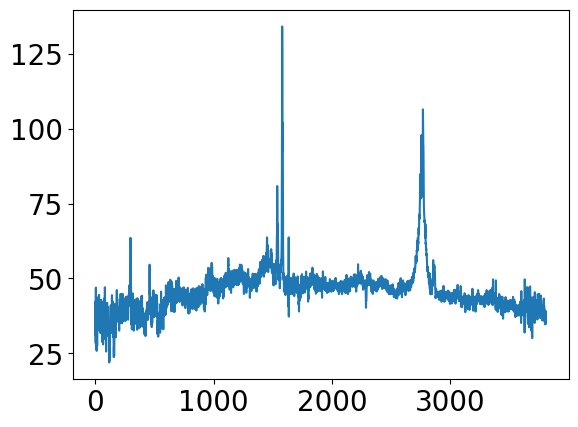

In [7]:
plt.plot(flux)